In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Dataset
df = pd.read_csv("./data/customer_shopping_data.csv")

df.head()


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [2]:
# Check null data
df.isnull().sum()


invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

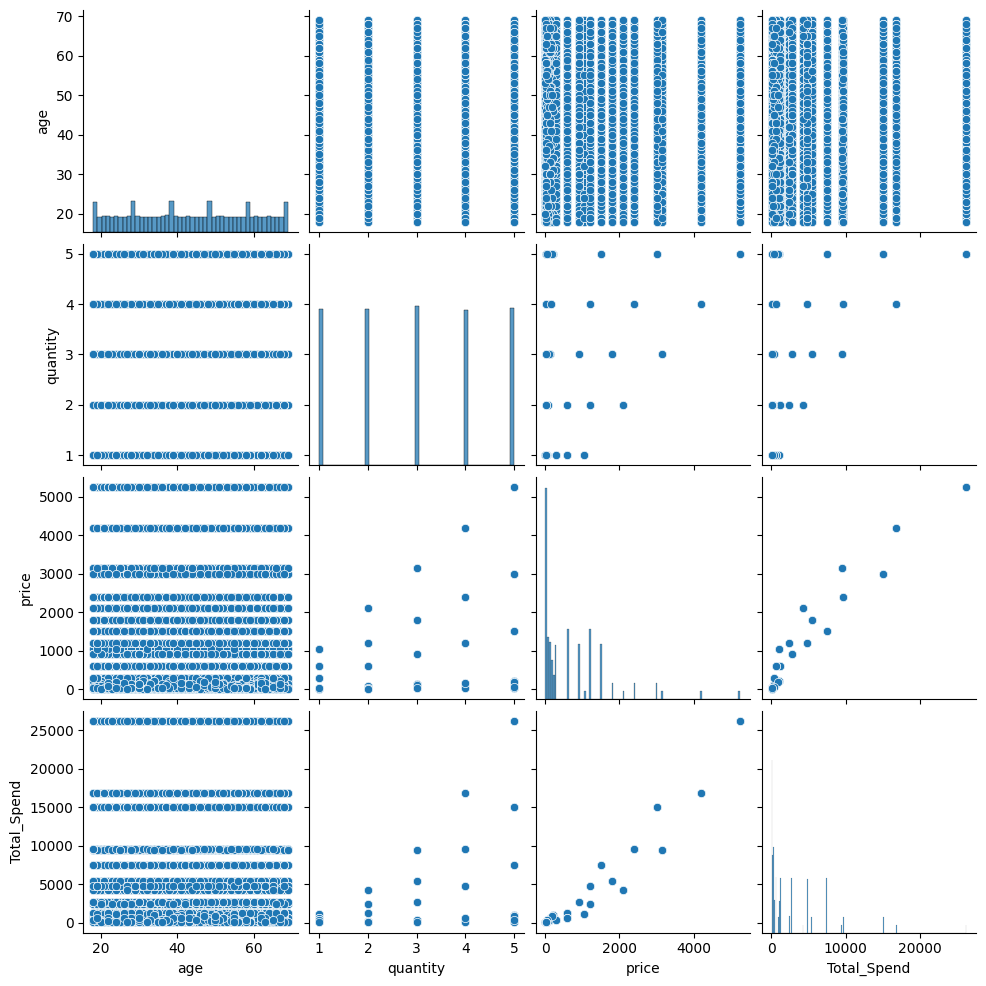

In [3]:
# Add data column
df['Total_Spend'] = df['quantity'] * df['price']

# Create pairwise scatterplots of data set
sns.pairplot(df)



Text(0, 0.5, 'Total Spend')

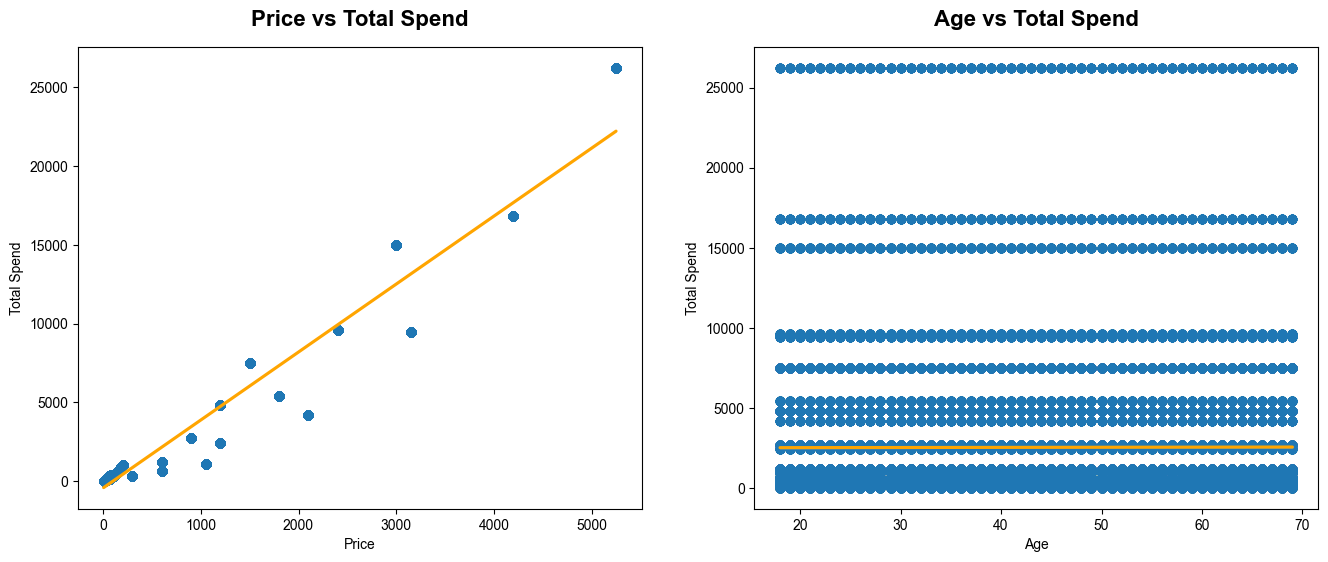

In [4]:
f, ax = plt.subplots(1,2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

sns.regplot(x = "price", y = "Total_Spend", data = df, line_kws={"color": "orange"},  ax=ax[0])
ax[0].set_title('Price vs Total Spend', fontsize=16, fontweight='bold', pad=15)
ax[0].set_xlabel('Price')
ax[0].set_ylabel('Total Spend')

sns.regplot(x = "age", y = "Total_Spend", data = df, line_kws={"color": "orange"}, ax=ax[1])
ax[1].set_title('Age vs Total Spend', fontsize=16, fontweight='bold', pad=15)
ax[1].set_xlabel('Age')
ax[1].set_ylabel('Total Spend')


Based on the pairplot visualization, we can draw the following key insights:

1. **Strong Linear Correlation (Total Spend vs. Price)**: There is a clear, positive linear correlation between Total_Spend and price. This aligns perfectly with expectations, as total spend is mathematically derived from multiplying price and quantity.

2. **Discrete Quantity Impact**: The quantity variable consists of fixed integer values (1 to 5), which creates distinct diagonal pathways when plotted against price and total spend, rather than a scattered continuous cloud.

3. **Zero Correlation between Age and Spending**: There is no linear correlation between age and any other financial variables (price, quantity, or Total_Spend). The uniform, grid-like distribution statistically proves that age has no impact on consumer spending behavior within this retail network. Young adults and seniors share an identical spending capacity per transaction.

In [5]:
# Subdata - Shopping Mall & Payment Method vs Total Spend
df = df[['category','payment_method','shopping_mall','Total_Spend']]
# Reset index
df.reset_index(inplace=True, drop=True)

df.head()

,category,payment_method,shopping_mall,Total_Spend
0,Clothing,Credit Card,Kanyon,7502.00
1,Shoes,Debit Card,Forum Istanbul,5401.53
2,Clothing,Cash,Metrocity,300.08
3,Shoes,Credit Card,Metropol AVM,15004.25
4,Books,Cash,Kanyon,242.40


In [6]:
# OLS Regression Analysis
from statsmodels.formula.api import ols
# Subset X and y variables
df_X = df[['category','payment_method','shopping_mall']]
df_y = df[['Total_Spend']]

ols_formula = "Total_Spend ~ C(category) + C(payment_method) + C(shopping_mall)"

OLS = ols(formula = ols_formula, data = df)
model = OLS.fit()

# Create a table to convert e to normal number
coef_table = model.summary().tables[1]
coef_df = pd.DataFrame(coef_table.data[1:], columns=coef_table.data[0])

# String to Float
for col in ['coef', 'std err', 't', 'P>|t|', '[0.025', '0.975]']:
    coef_df[col] = pd.to_numeric(coef_df[col], errors='coerce')
coef_df.set_index('', inplace=True)

pd.set_option('display.float_format', lambda x: '%.2f' % x)

coef_df


,coef,std err,t,P>|t|,[0.025,0.975]
,,,,,,
Intercept,187.83,60.89,3.08,0.00,68.49,307.17
C(category)[T.Clothing],3138.40,46.00,68.22,0.00,3048.24,3228.57
C(category)[T.Cosmetics],282.77,49.59,5.70,0.00,185.56,379.97
C(category)[T.Food & Beverage],-109.55,49.73,-2.20,0.03,-207.01,-12.09
C(category)[T.Shoes],6465.53,52.61,122.90,0.00,6362.43,6568.64
C(category)[T.Souvenir],-40.16,60.76,-0.66,0.51,-159.26,78.93
C(category)[T.Technology],11410.00,60.77,187.84,0.00,11300.00,11500.00
C(category)[T.Toys],227.31,52.56,4.33,0.00,124.29,330.32
C(payment_method)[T.Credit Card],-12.02,21.70,-0.55,0.58,-54.55,30.52


Insights from OLS Regression Analysis:
1. **Category is the Dominant Predictor**: Product category has a highly significant linear relationship with Total_Spend (p < 0.001). Specifically, Technology ($+11,410 TL) and Shoes ($+6,465 TL) are the strongest linear drivers that dramatically lift transaction values.

2. **Payment Method has Zero Impact**: Both credit card (p = 0.58) and debit card (p = 0.50) show no statistically significant correlation with total spend, proving that how customers pay does not influence how much they buy per transaction.

3. **Location/Mall Doesn't Change Basket Size**: Almost all shopping malls yield p-values well above 0.05. This indicates that while some malls generate higher overall revenue due to higher foot traffic, the average spend per transaction remains identical across all 10 locations.